In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt # This is the package that allows us to plot data

In [2]:
# First, let's import our data from last week

cafe_sales = pd.read_csv('cafe_data.csv')
cafe_sales.head()

,Transaction ID,Item,Quantity,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,4.0,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,12.0,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,4.0,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,10.0,Unknown,Unknown,4/27/2023
4,TXN_3160411,Coffee,2,4.0,Digital Wallet,In-store,6/11/2023


## Let's use Pandas to get basic information about our data

In [6]:
# df.info() provides column non-null counts and data types
cafe_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9486 entries, 0 to 9485
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9486 non-null   object 
 1   Item              9486 non-null   object 
 2   Quantity          9486 non-null   int64  
 3   Total Spent       9486 non-null   float64
 4   Payment Method    9486 non-null   object 
 5   Location          9486 non-null   object 
 6   Transaction Date  9152 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 518.9+ KB


In [7]:
# df.describe() calculates summary statistics for numerical variables
cafe_sales.describe()

,Quantity,Total Spent
count,9486.000000,9486.000000
mean,3.030150,8.943654
std,1.420068,6.012609
min,1.000000,1.000000
25%,2.000000,4.000000
50%,3.000000,8.000000
75%,4.000000,12.000000
max,5.000000,25.000000


## Grouping and Aggregation
Grouping or aggregating our data by variables is very helpful when making visualizations.

- df.groupby(Categorical Variable)[Quantitative Variable].mean()
- df.groupby(Categorical Variable)[Quantitative Variable].sum()

This separates our data by the specified Categorical Variable, and then performs an operation, such as mean or sum, with the Quantitative Variable.

In [10]:
# Find the average Total Spent for each unique Payment Method
cafe_sales.groupby('Payment Method')['Total Spent'].mean()

,Total Spent
Payment Method,
Cash,9.067854
Credit Card,9.046512
Digital Wallet,8.938776
Unknown,8.765659


In [11]:
# Find the sum of Total Spent for each Item
cafe_sales.groupby('Item')['Total Spent'].sum()

,Total Spent
Item,
Cake,10092.0
Coffee,6920.0
Cookie,3135.0
Juice,10248.0
Salad,16820.0
Sandwich,13312.0
Smoothie,12904.0
Tea,4785.0
Unknown,6623.5


## Let's learn some basics of Matplotlib:

Matplotlib offers a variety of plot types, here are some examples:
- **plt.hist()** = histogram
- **plt.scatter()** = scatterplot
- **plt.bar()** or **plt.barh()** = vertical or horizontal bar charts
- **plt.boxplot()** = box and whisker plot
- **plt.pie()** = pie chart

There also many functions to tinker with plot appearance:
- **plt.title()** = gives the plot a title at the top
- **plt.xlabel()** = gives a label for x-axis
- **plt.ylabel()** = gives a label for y-axis
- **plt.show()** = displays the plot


### Histogram

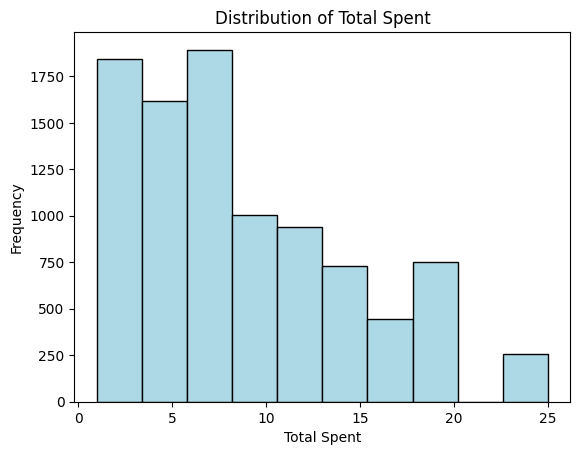

In [14]:
plt.hist(cafe_sales['Total Spent'], color='lightblue', edgecolor='black')
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

### Boxplot

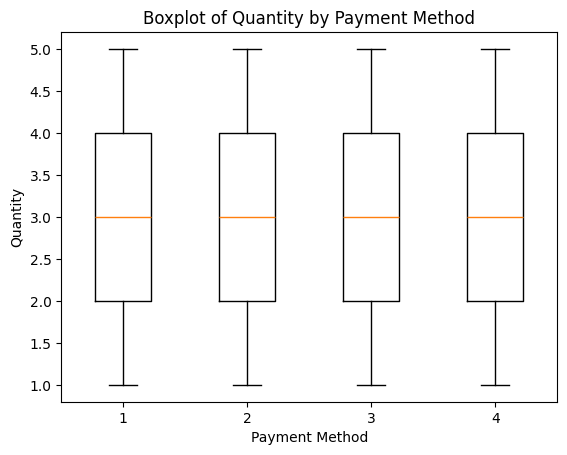

In [13]:
# Mutliple boxplots to compare Quantity and Payment Method
fig, ax = plt.subplots()
ax.boxplot([cafe_sales[cafe_sales['Payment Method'] == 'Credit Card']['Quantity'],
            cafe_sales[cafe_sales['Payment Method'] == 'Cash']['Quantity'],
            cafe_sales[cafe_sales['Payment Method'] == 'Digital Wallet']['Quantity'],
            cafe_sales[cafe_sales['Payment Method'] == 'Unknown']['Quantity']])
plt.title('Boxplot of Quantity by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Quantity')
plt.show()

### Bar Chart

In [16]:
# Use .value_counts() to count each unique Item
cafe_sales['Item'].value_counts()

,count
Item,
Juice,1140
Coffee,1132
Salad,1109
Cake,1101
Sandwich,1095
Smoothie,1054
Cookie,1054
Tea,1051
Unknown,750


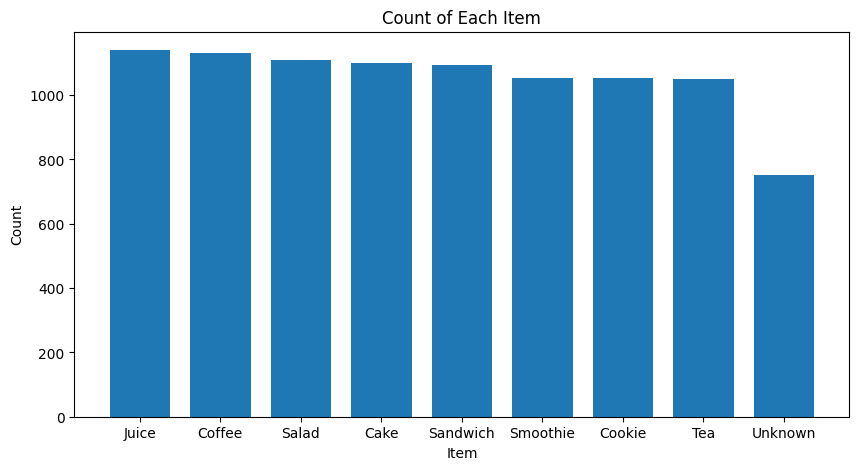

In [17]:
plt.figure(figsize=(10,5))
plt.bar(cafe_sales['Item'].value_counts().index, cafe_sales['Item'].value_counts(), width=0.75)
plt.title('Count of Each Item')
plt.xlabel('Item')
plt.ylabel('Count')
plt.show()

### Scatterplot

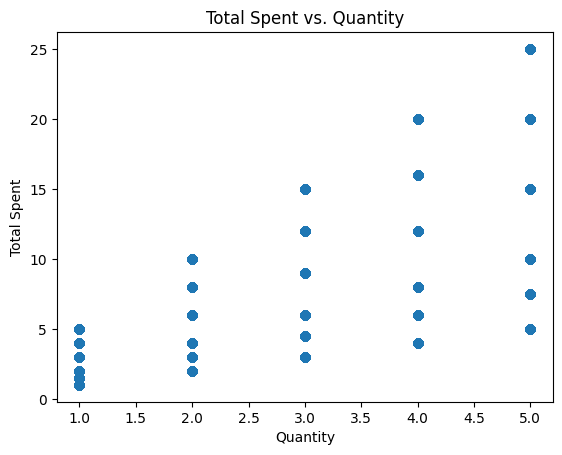

In [15]:
plt.scatter(cafe_sales['Quantity'], cafe_sales['Total Spent'])
plt.title('Total Spent vs. Quantity')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()

### Scatterplot with Line of Best Fit

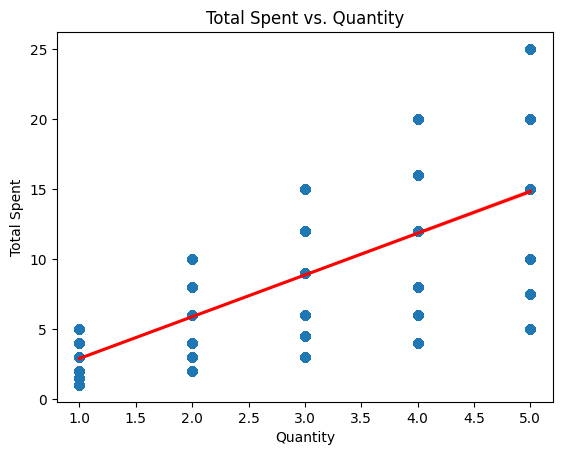

In [17]:
sns.regplot(x='Quantity', y='Total Spent', data=cafe_sales, line_kws=dict(color="r"))
plt.title('Total Spent vs. Quantity')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()